In [1]:
import numpy as np
import glob
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from IPython.display import display, Markdown
import os

In [2]:
# parameters for dev3 annotated_usages and release1 results

annotations_path = "../../../data/dev3/annotated_usages/**/*usage_sample.tsv"
mappings_path = "../../../data/dev3/annotated_usages/**/*mappings.tsv"

#result_raw_path = "../../../data/dev3/filtered_results/release_1/s1/result_raw.tsv.zst"
#step = "S1"
result_raw_path = "../../../data/dev3/filtered_results/release_1/s3/result_raw.tsv.zst"
step = "S3"

lemur_path = "../../../data/dev3/dictionaries/lemur_dictionary.tsv"
ode_path = "../../../data/dev3/dictionaries/ode_dictionary.tsv"

result_name = result_raw_path.split("/")[-3]
out_dir = f"../plots/prob_distribution/{result_name}"  # where to save plots
os.makedirs(out_dir, exist_ok=True)

In [4]:
# read annotated usages
annotation_paths = glob.glob(annotations_path, recursive=True)
df_annotation = pd.concat([pd.read_csv(a, sep="\t", dtype=str, encoding="utf-8") for a in annotation_paths])
df_annotation = df_annotation[["sense_id", "identifier", "lemma"]].rename(columns={"sense_id": "annotation_id"})

# only use first named sense_id annotation
df_annotation["annotation_id"] = df_annotation["annotation_id"].apply(lambda sense_id: sense_id.split(",")[0].strip())

# read sense_id mappings from annotated_usages
mapping_paths = glob.glob(mappings_path, recursive=True)
df_mapping = pd.concat([pd.read_csv(m, sep="\t", dtype=str, encoding="utf-8") for m in mapping_paths])

# create dictionary with sense_id mappings
mapping_dict = {}
for _,row in df_mapping.iterrows():
    mapping_dict[(row["lemma"], row["new_sense_id"])] = row["old_sense_id"]

# apply sense_id mappings to get original sense_ids from simplified ones (e.g. 1 -> LMR-1573)
df_annotation["annotation_id"] = df_annotation.apply(lambda r: mapping_dict.get((r["lemma"], r["annotation_id"]), r["annotation_id"]), axis=1)

# read lemur dictionary
lemur_paths = glob.glob(lemur_path, recursive=True)
df_lemur = pd.concat([pd.read_csv(l, sep="\t", dtype=str, encoding="utf-8") for l in lemur_paths])
df_lemur = df_lemur[["sense_id", "lemma"]].rename(columns={"sense_id": "lemur_id"})
df_lemur = df_lemur[df_lemur["lemma"].isin(set(df_annotation["lemma"].tolist()))]
lemur_sense_ids = set(df_lemur["lemur_id"].tolist())

# read ode dictionary
ode_paths = glob.glob(ode_path, recursive=True)
df_ode = pd.concat([pd.read_csv(o, sep="\t", dtype=str, encoding="utf-8") for o in ode_paths])
ode_lemmas = df_ode["lemma"].tolist()
ode_sense_ids = set(df_ode["sense_id"].tolist())

df_annotation["in_ode"] = df_annotation["lemma"].apply(lambda r: r in ode_lemmas)

df_annotation["class"] = pd.NA
df_annotation.loc[df_annotation["annotation_id"].isin(ode_sense_ids), "class"] = "recorded"
df_annotation.loc[df_annotation["annotation_id"].isin(lemur_sense_ids), "class"] = "lemur"
df_annotation.loc[df_annotation["annotation_id"] == "x", "class"] = "x"
df_annotation.loc[df_annotation["annotation_id"] == "0", "class"] = "0"
df_annotation["class"] = df_annotation["class"].fillna("unrecorded")

df_invalid = df_annotation[df_annotation.isna().any(axis=1)]
df_annotation = df_annotation[~df_annotation.isna().any(axis=1)]

pd.set_option("display.max_rows", None)
display(df_annotation.sample(n=min(8,len(df_annotation))))

if not df_invalid.empty:
    display(Markdown("### invalid rows removed:"))
    display(df_invalid.sample(n=len(df_invalid)))

,annotation_id,identifier,lemma,in_ode,class
29,m_en_gbus1207913.004,NOW-2102GB-62627148-19149469966,prefill,True,recorded
71,-1,NOW-2412US3-119012744-34510073484,hale,True,unrecorded
34,m_en_gbus0373730.015,NOW-1708HK-19991390-7119620331,flow,True,recorded
45,m_en_gbus0447670.011,NOW-1706IE-18980172-6687634485,hammer,True,recorded
13,m_en_gbus0081140.012,NOW-1507NG-1925915-2820818056,beast,True,recorded
9,LMR2-73446,NOW-2201US3-88639742-23055770148,Occidentalism,False,lemur
9,-1,NOW-2209SG-93520472-26187078928,anchor,True,unrecorded
7,LMR2-56162,NOW-2105US3-87287651-20448920182,capture-the-flag,False,lemur


In [5]:
df_result_raw = pd.read_csv(result_raw_path, sep="\t", dtype={"prob": float, "sense_id": str}, encoding="utf-8")
df_result_raw = df_annotation.merge(df_result_raw, on=["lemma", "identifier"], how="inner")

### Basic Stats S3

---

Total Usages: 1755
In-ODE Usages: 1186
Out-ODE Usages: 569
Recorded Usages: 652
Unrecorded Usages: 689
x Usages: 3
0 Usages: 41


---

LEMUR Usages: 370
LEMUR Usages Out-ODE: 305
LEMUR Usages In-ODE: 65


---

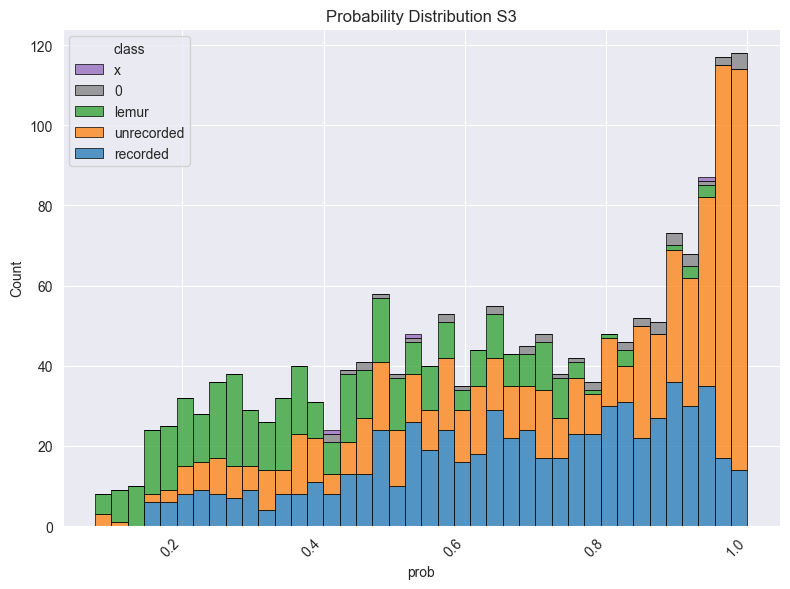

In [6]:
colors = sns.color_palette("tab10")
custom_palette_lemur = {True: colors[2], False: colors[0]}
custom_palette = {"x": colors[4], "0": colors[7], "lemur": colors[2], "unrecorded": colors[1], "recorded": colors[0]}

df_in_ode = df_result_raw[df_result_raw["in_ode"]]
df_out_ode = df_result_raw[~df_result_raw["in_ode"]]
df_lemur = df_result_raw[df_result_raw["class"] == "lemur"]
df_unrecorded = df_result_raw[df_result_raw["class"] == "unrecorded"]
df_recorded = df_result_raw[df_result_raw["class"] == "recorded"]
df_x = df_result_raw[df_result_raw["class"] == "x"]
df_0 = df_result_raw[df_result_raw["class"] == "0"]
df_lemur_in_ode = df_result_raw[df_result_raw["in_ode"] & (df_result_raw["class"] == "lemur")]
df_lemur_out_ode = df_result_raw[~df_result_raw["in_ode"] & (df_result_raw["class"] == "lemur")]

display(Markdown(f"### Basic Stats {step}"))
display(Markdown("---"))
print(f"Total Usages: {len(df_result_raw)}")
print(f"In-ODE Usages: {len(df_in_ode)}")
print(f"Out-ODE Usages: {len(df_out_ode)}")
print(f"Recorded Usages: {len(df_recorded)}")
print(f"Unrecorded Usages: {len(df_unrecorded)}")
print(f"x Usages: {len(df_x)}")
print(f"0 Usages: {len(df_0)}")
display(Markdown("---"))
print(f"LEMUR Usages: {len(df_lemur)}")
print(f"LEMUR Usages Out-ODE: {len(df_lemur_out_ode)}")
print(f"LEMUR Usages In-ODE: {len(df_lemur_in_ode)}")
display(Markdown("---"))


plt.figure(figsize=(8,6))
sns.histplot(data=df_result_raw, x="prob", hue="class", hue_order=["x", "0", "lemur", "unrecorded", "recorded"], palette=custom_palette, fill=True, bins=40, multiple="stack", linewidth=0.5, edgecolor="black")
plt.title(f"Probability Distribution {step}")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig(out_dir + f"/{step}_hist.png", dpi=400)
plt.show()

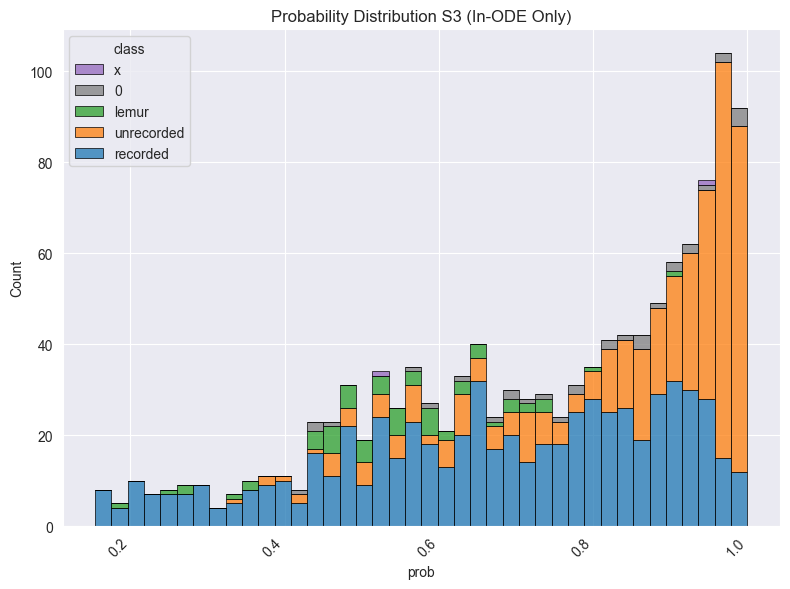

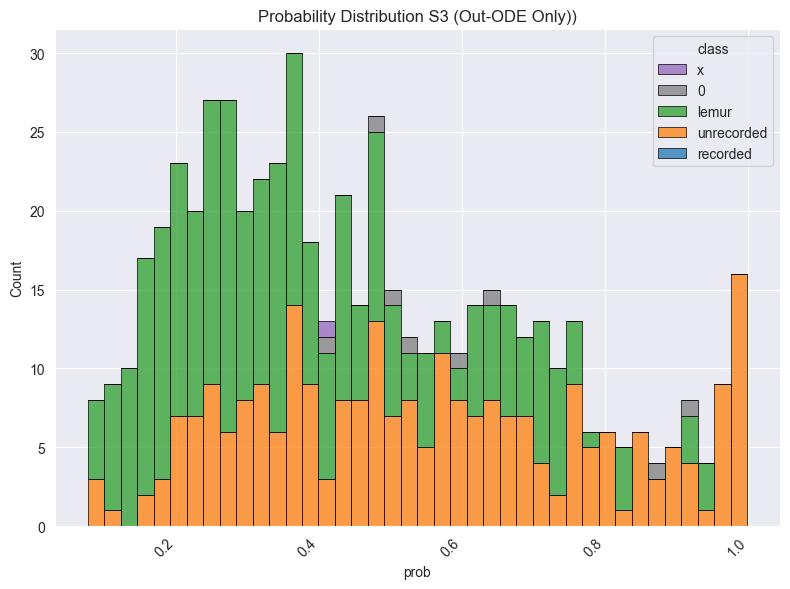

In [7]:
plt.figure(figsize=(8,6))
sns.histplot(data=df_in_ode, x="prob", hue="class", hue_order=["x", "0", "lemur", "unrecorded", "recorded"], palette=custom_palette, fill=True, bins=40, multiple="stack", linewidth=0.5, edgecolor="black")
plt.title(f"Probability Distribution {step} (In-ODE Only)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig(out_dir + f"/{step}_hist_in_ode.png", dpi=400)
plt.show()

plt.figure(figsize=(8,6))
sns.histplot(data=df_out_ode, x="prob", hue="class", hue_order=["x", "0", "lemur", "unrecorded", "recorded"], palette=custom_palette, fill=True, bins=40, multiple="stack", linewidth=0.5, edgecolor="black")
plt.title(f"Probability Distribution {step} (Out-ODE Only))")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig(out_dir + f"/{step}_hist_out_ode.png", dpi=400)
plt.show()

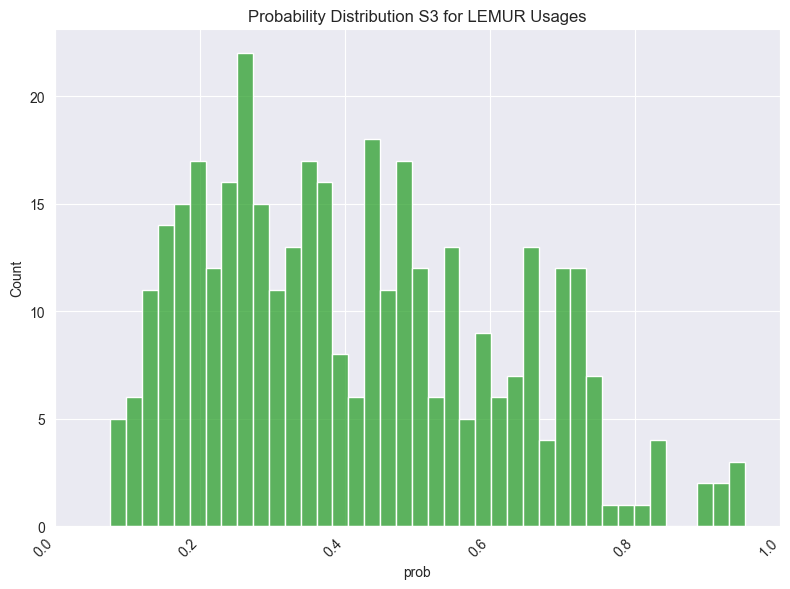

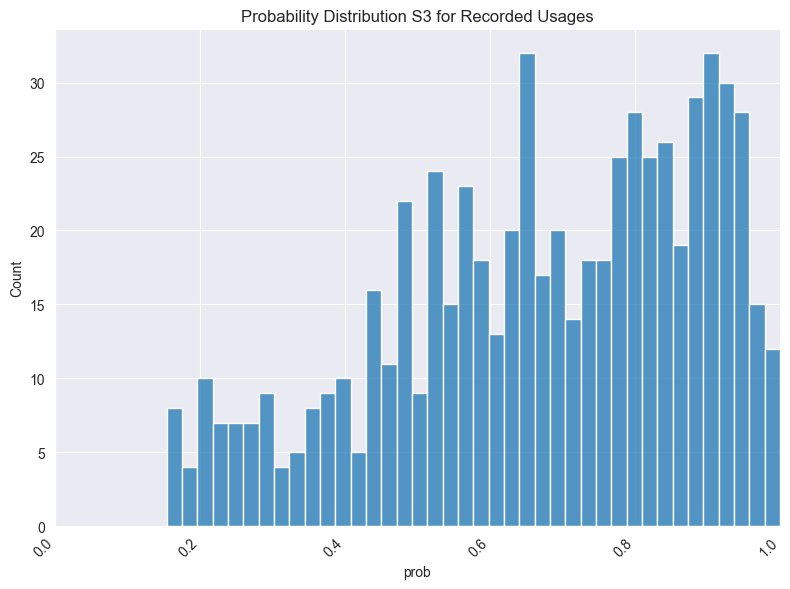

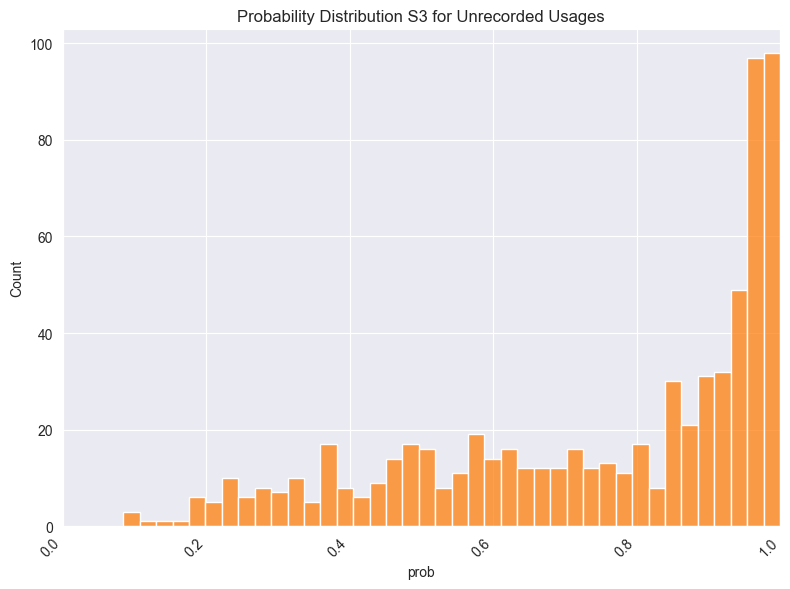

In [8]:
plt.figure(figsize=(8,6))
sns.histplot(data=df_lemur , x="prob",fill=True, bins=40, multiple="stack", hue_order=[True, False], color=colors[2])
plt.title(f"Probability Distribution {step} for LEMUR Usages")
plt.xticks(rotation=45, ha="right")
plt.xlim(0, 1.0)
plt.tight_layout()
plt.savefig(out_dir + f"/{step}_hist_LEMUR.png", dpi=400)
plt.show()

plt.figure(figsize=(8,6))
sns.histplot(data=df_recorded , x="prob",fill=True, bins=40, multiple="stack", hue_order=[True, False], color=colors[0])
plt.title(f"Probability Distribution {step} for Recorded Usages")
plt.xticks(rotation=45, ha="right")
plt.xlim(0, 1.0)
plt.tight_layout()
plt.savefig(out_dir + f"/{step}_hist_recorded.png", dpi=400)
plt.show()

plt.figure(figsize=(8,6))
sns.histplot(data=df_unrecorded , x="prob",fill=True, bins=40, multiple="stack", hue_order=[True, False], color=colors[1])
plt.title(f"Probability Distribution {step} for Unrecorded Usages")
plt.xticks(rotation=45, ha="right")
plt.xlim(0, 1.0)
plt.tight_layout()
plt.savefig(out_dir + f"/{step}_hist_unrecorded.png", dpi=400)
plt.show()

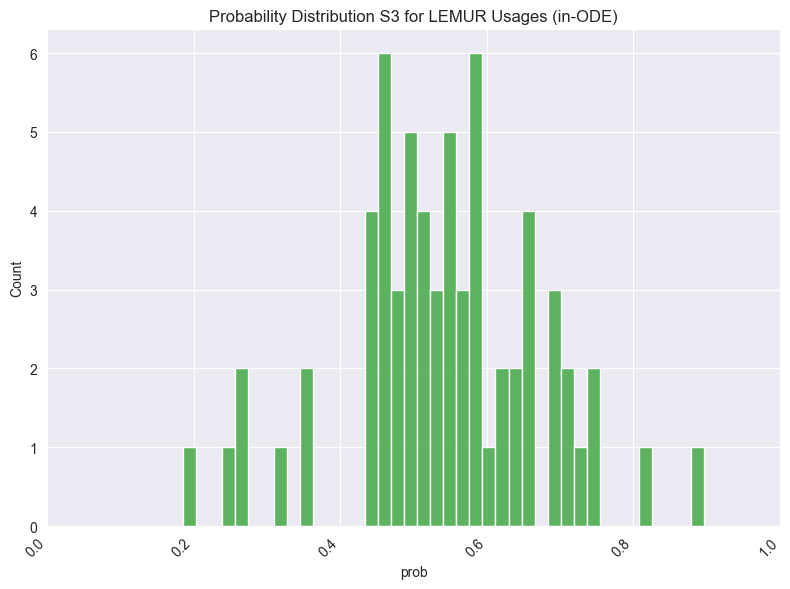

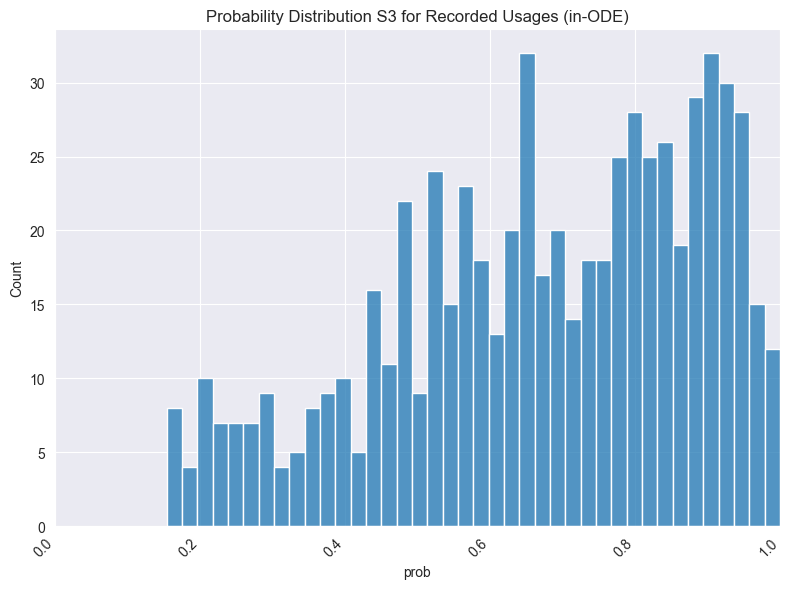

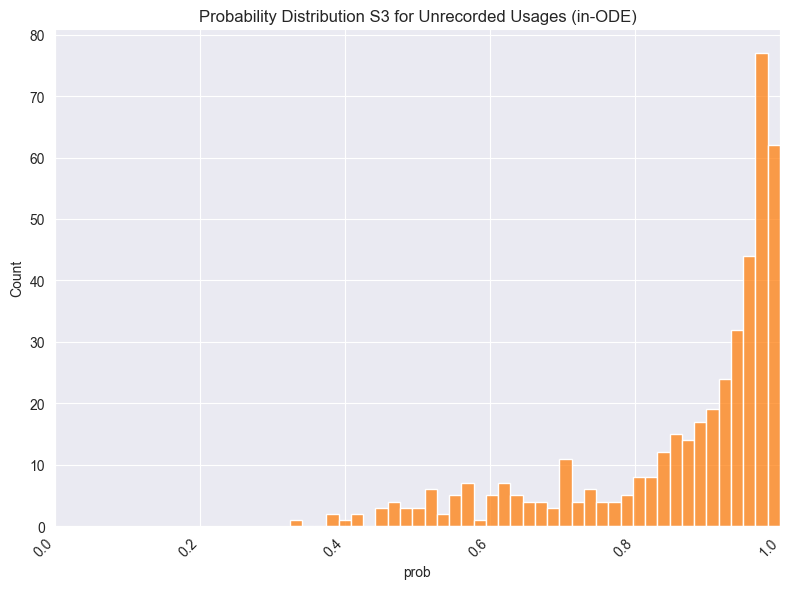

In [9]:
plt.figure(figsize=(8,6))
sns.histplot(data=df_lemur[df_lemur["in_ode"]] , x="prob",fill=True, bins=40, multiple="stack", hue_order=[True, False], color=colors[2])
plt.title(f"Probability Distribution {step} for LEMUR Usages (in-ODE)")
plt.xticks(rotation=45, ha="right")
plt.xlim(0, 1.0)
plt.tight_layout()
plt.savefig(out_dir + f"/{step}_hist_LEMUR_in_ode.png", dpi=400)
plt.show()

plt.figure(figsize=(8,6))
sns.histplot(data=df_recorded[df_recorded["in_ode"]] , x="prob",fill=True, bins=40, multiple="stack", hue_order=[True, False], color=colors[0])
plt.title(f"Probability Distribution {step} for Recorded Usages (in-ODE)")
plt.xticks(rotation=45, ha="right")
plt.xlim(0, 1.0)
plt.tight_layout()
plt.savefig(out_dir + f"/{step}_hist_recorded_in_ode.png", dpi=400)
plt.show()

plt.figure(figsize=(8,6))
sns.histplot(data=df_unrecorded[df_unrecorded["in_ode"]] , x="prob",fill=True, bins=40, multiple="stack", hue_order=[True, False], color=colors[1])
plt.title(f"Probability Distribution {step} for Unrecorded Usages (in-ODE)")
plt.xticks(rotation=45, ha="right")
plt.xlim(0, 1.0)
plt.tight_layout()
plt.savefig(out_dir + f"/{step}_hist_unrecorded_in_ode.png", dpi=400)
plt.show()

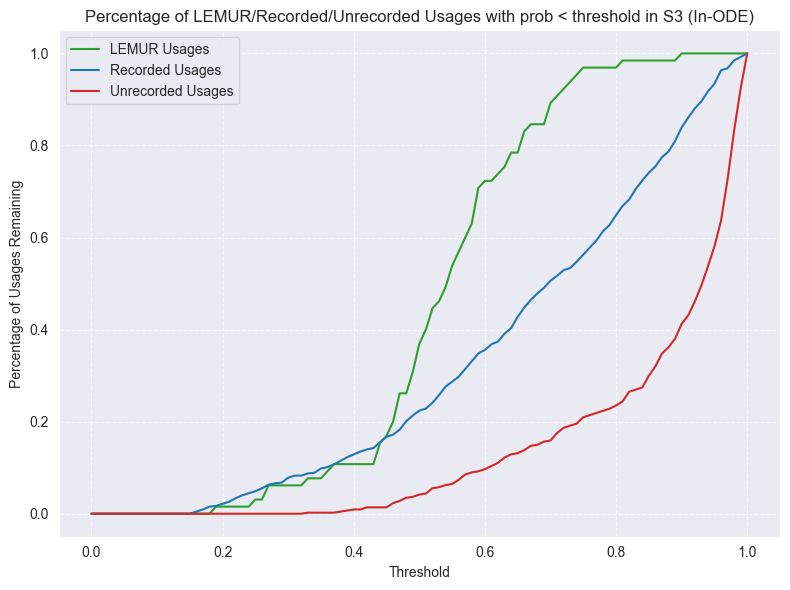

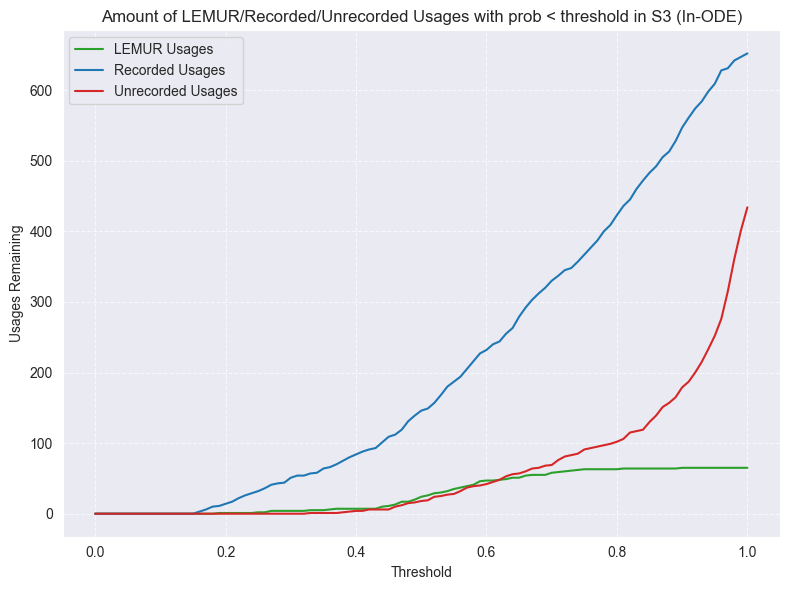

In [10]:
import sys

df_clean = df_in_ode[~df_in_ode["class"].isin(["x", "0"])]

total_lemur = len(df_clean[df_clean["class"] == "lemur"])
total_recorded = len(df_clean[df_clean["class"] == "recorded"])
total_unrecorded = len(df_clean[df_clean["class"]=="unrecorded"])

thresholds = np.linspace(0, 1, 101)
lemur_percentage = []
recorded_percentage = []
unrecorded_percentage = []
lemur_unrecorded_percentage = []

lemur_remaining = []
recorded_remaining = []
unrecorded_remaining = []
lemur_unrecorded_remaining = []

for t in thresholds:
    # apply threshold
    if step == "S1":
        lemur_thresh = len(df_clean[(df_clean["class"] == "lemur") & (df_clean["prob"] > t)])
        recorded_thresh = len(df_clean[(df_clean["class"] == "recorded") & (df_clean["prob"] > t)])
        unrecorded_thresh = len(df_clean[(df_clean["class"] == "unrecorded") & (df_clean["prob"] > t)])
    elif step == "S3":
        lemur_thresh = len(df_clean[(df_clean["class"] == "lemur") & (df_clean["prob"] < t)])
        recorded_thresh = len(df_clean[(df_clean["class"] == "recorded") & (df_clean["prob"] < t)])
        unrecorded_thresh = len(df_clean[(df_clean["class"] == "unrecorded") & (df_clean["prob"] < t)])
    else:
        print("specify parameter 'step'. Should be either 'S1' or 'S3'")
        sys.exit(0)

    lemur_recorded_thresh = unrecorded_thresh + lemur_thresh

    # to plot amount of remaining usages
    lemur_remaining.append(lemur_thresh)
    recorded_remaining.append(recorded_thresh)
    unrecorded_remaining.append(unrecorded_thresh)
    lemur_unrecorded_remaining.append(lemur_recorded_thresh)

    # to plot percentage of remaining usages
    lemur_percentage.append(lemur_thresh / total_lemur if total_lemur > 0 else 0)
    recorded_percentage.append(recorded_thresh / total_recorded if total_recorded > 0 else 0)
    unrecorded_percentage.append(unrecorded_thresh / total_unrecorded if total_recorded > 0 else 0)
    lemur_unrecorded_percentage.append(lemur_recorded_thresh / (total_lemur+total_unrecorded) if (total_lemur+total_unrecorded) > 0 else 0)

# Plot
plt.figure(figsize=(8,6))
plt.plot(thresholds, lemur_percentage, label="LEMUR Usages", color="tab:green")
plt.plot(thresholds, recorded_percentage, label="Recorded Usages", color="tab:blue")
plt.plot(thresholds, unrecorded_percentage, label="Unrecorded Usages", color="tab:red")
#plt.plot(thresholds, lemur_unrecorded_percentage, label="Unrecorded + LEMUR Usages", color="tab:orange")
plt.xlabel("Threshold")
plt.ylabel("Percentage of Usages Remaining")
plt.title(f"Percentage of LEMUR/Recorded/Unrecorded Usages with prob {'>' if step == 'S1' else '<'} threshold in {step} (In-ODE)")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.7)
plt.tight_layout()
plt.savefig(out_dir + f"/{step}_lineplot_distribution_percentage", dpi=400)
plt.show()

# Plot
plt.figure(figsize=(8,6))
plt.plot(thresholds, lemur_remaining, label="LEMUR Usages", color="tab:green")
plt.plot(thresholds, recorded_remaining, label="Recorded Usages", color="tab:blue")
plt.plot(thresholds, unrecorded_remaining, label="Unrecorded Usages", color="tab:red")
#plt.plot(thresholds, lemur_unrecorded_remaining, label="Unrecorded + LEMUR Usages", color="tab:orange")
plt.xlabel("Threshold")
plt.ylabel("Usages Remaining")
plt.title(f"Amount of LEMUR/Recorded/Unrecorded Usages with prob {'>' if step == 'S1' else '<'} threshold in {step} (In-ODE)")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.7)
plt.tight_layout()
plt.savefig(out_dir + f"/{step}_lineplot_distribution_count", dpi=400)
plt.show()

### Probability Distribution per Lemma

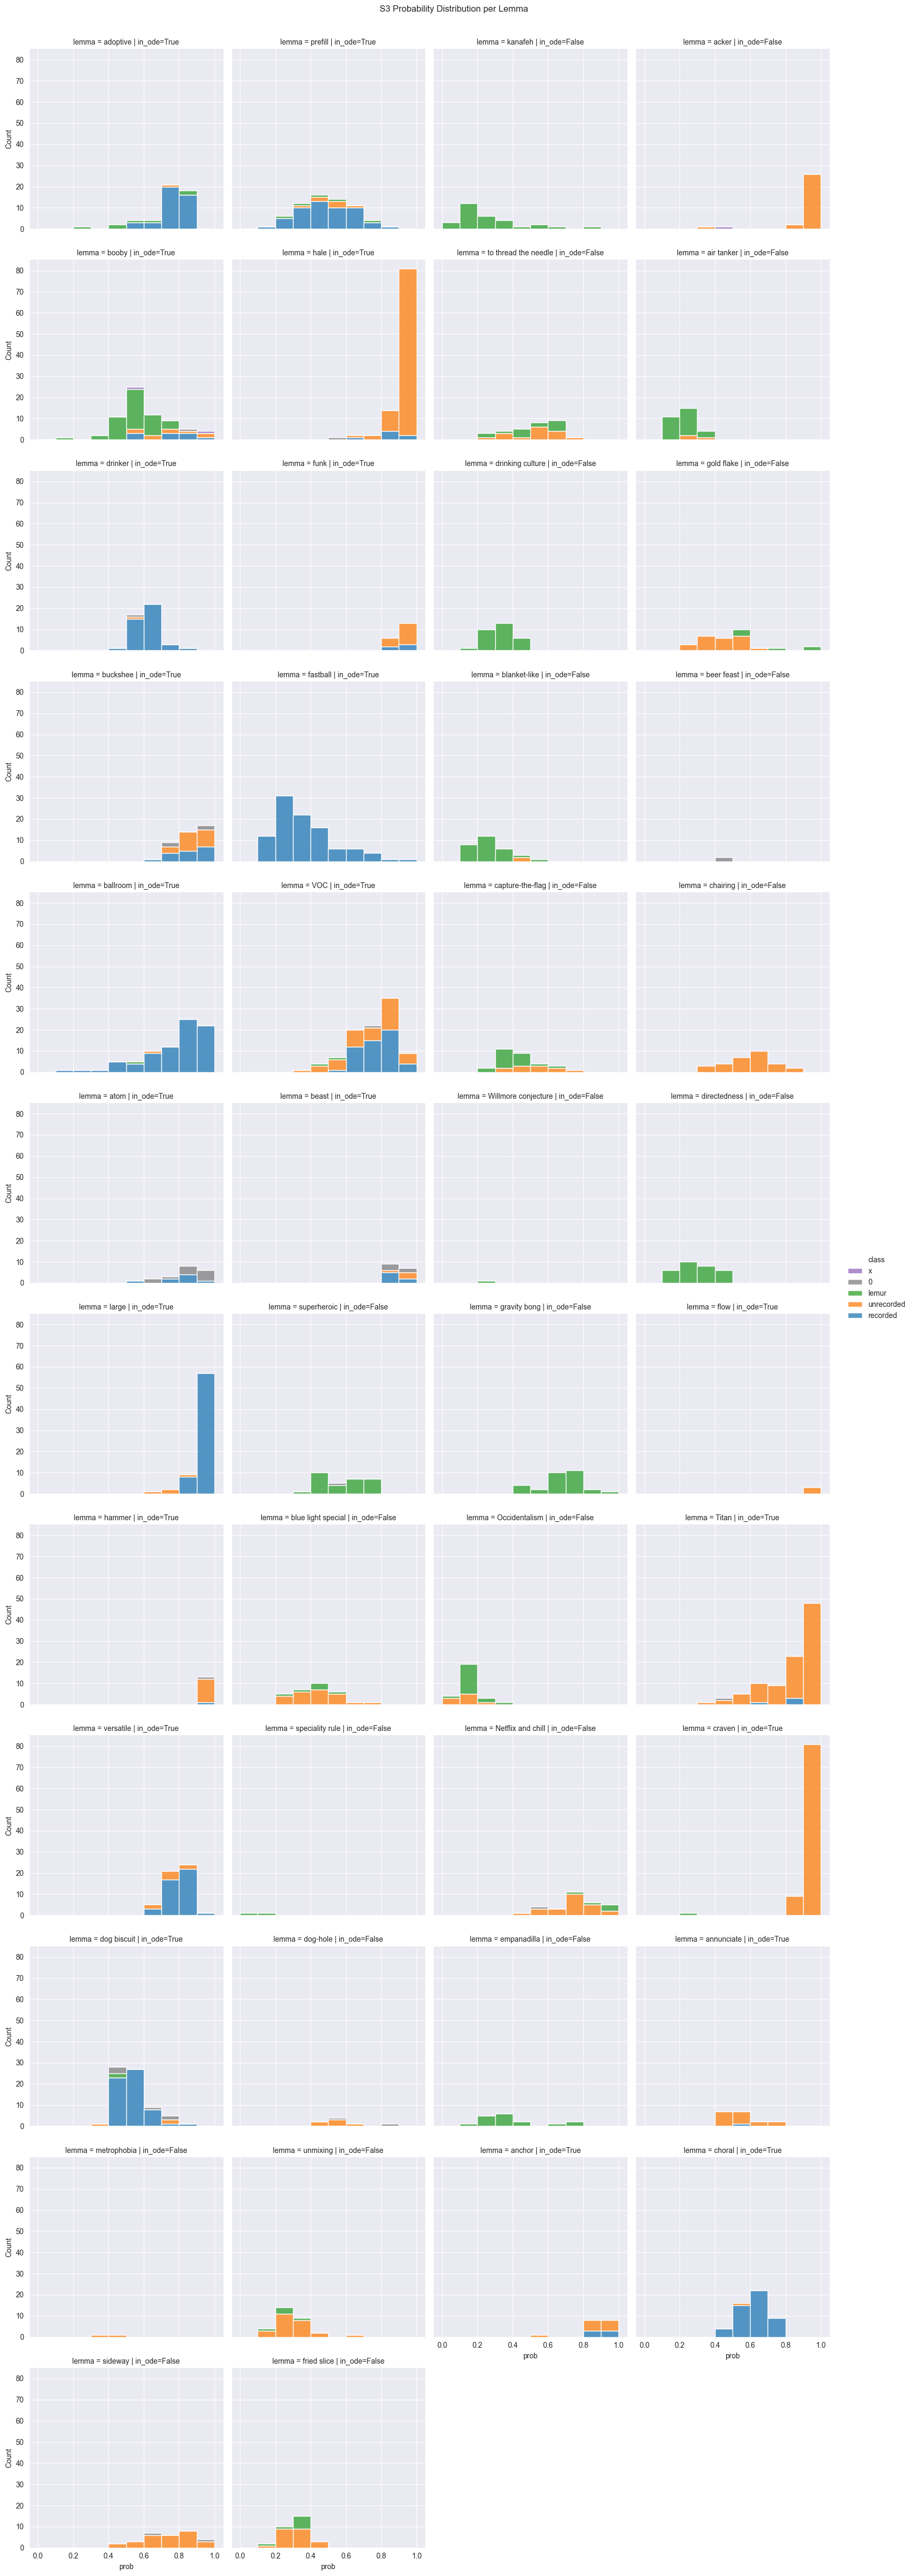

In [11]:
import numpy as np

display(Markdown("### Probability Distribution per Lemma"))
bins = np.linspace(0, 1, 11)

df_result_with_title = df_result_raw.copy()
df_result_with_title["lemma"] = (df_result_with_title["lemma"] + " | in_ode=" + df_result_with_title["in_ode"].astype(str))
g = sns.displot(df_result_with_title, x="prob", col="lemma", col_wrap=4, height=4, hue="class", palette=custom_palette, bins=bins, multiple="stack", hue_order=["x", "0", "lemur", "unrecorded", "recorded"])
g.fig.suptitle(f"{step} Probability Distribution per Lemma", y=1.01)
plt.savefig(out_dir + f"/{step}_hist_per_lemma", dpi=400, bbox_inches="tight")
plt.show()